# Step 2: Data Cleaning & Preprocessing

In this notebook, we perform data preprocessing on the merged market dataset. We will:
1. Convert the Date column to Datetime format and sort.
2. Check and remove duplicate rows.
3. Check for missing values and fill them using Forward Fill followed by Backward Fill.
4. Inspect statistical descriptions and detect outliers using boxplots.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/processed/market_data.csv")
print(f"Loaded dataset shape: {df.shape}")
df.head()

Loaded dataset shape: (3928, 10)


,Date,NIFTY_Close,NIFTY_High,NIFTY_Low,NIFTY_Open,Volume,Gold,Oil,USD_INR,India_VIX
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0,1117.699951,81.510002,46.287998,23.639999
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0,1118.099976,81.769997,46.119999,22.270000
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0,1135.900024,83.180000,45.720001,22.120001
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0,1133.099976,82.660004,45.688000,22.500000
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0,1138.199951,82.750000,45.518002,22.570000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3928 entries, 0 to 3927
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         3928 non-null   str    
 1   NIFTY_Close  3928 non-null   float64
 2   NIFTY_High   3928 non-null   float64
 3   NIFTY_Low    3928 non-null   float64
 4   NIFTY_Open   3928 non-null   float64
 5   Volume       3928 non-null   int64  
 6   Gold         3818 non-null   float64
 7   Oil          3819 non-null   float64
 8   USD_INR      3920 non-null   float64
 9   India_VIX    3912 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 307.0 KB


In [4]:
# Convert Date column and sort
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.reset_index(drop=True, inplace=True)
print("Date converted and sorted chronologically.")

Date converted and sorted chronologically.


In [5]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped.")

Number of duplicate rows: 0


In [6]:
missing = df.isnull().sum()
print("=== Missing values per column ===")
print(missing)

=== Missing values per column ===
Date             0
NIFTY_Close      0
NIFTY_High       0
NIFTY_Low        0
NIFTY_Open       0
Volume           0
Gold           110
Oil            109
USD_INR          8
India_VIX       16
dtype: int64


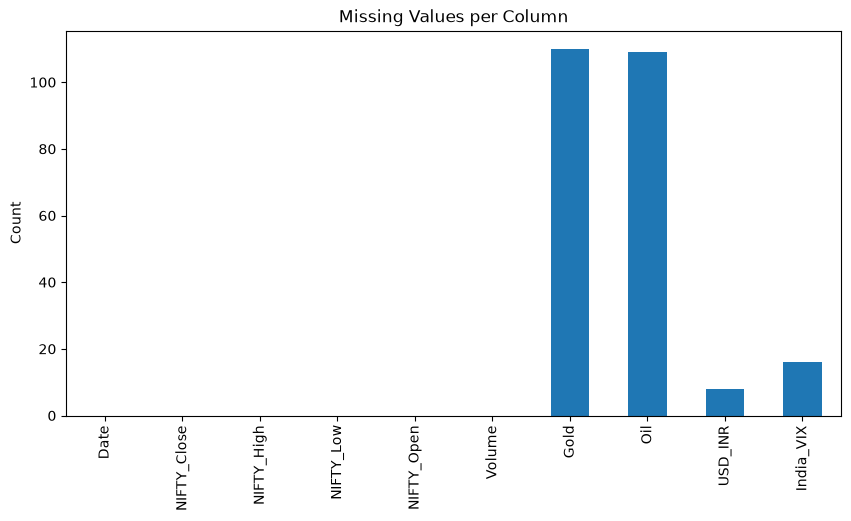

In [7]:
# Plot missing values
plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

In [8]:
# Fill missing values
df = df.ffill()
df = df.bfill()
print("Filled missing values using ffill then bfill.")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Filled missing values using ffill then bfill.
Remaining missing values: 0


In [9]:
print("=== DATA TYPES ===")
print(df.dtypes)

=== DATA TYPES ===
Date           datetime64[us]
NIFTY_Close           float64
NIFTY_High            float64
NIFTY_Low             float64
NIFTY_Open            float64
Volume                  int64
Gold                  float64
Oil                   float64
USD_INR               float64
India_VIX             float64
dtype: object


In [10]:
df.describe()

,Date,NIFTY_Close,NIFTY_High,NIFTY_Low,NIFTY_Open,Volume,Gold,Oil,USD_INR,India_VIX
count,3928,3928.000000,3928.000000,3928.000000,3928.000000,3.928000e+03,3928.000000,3928.000000,3928.000000,3928.000000
mean,2018-01-06 16:12:35.193482,11834.883777,11898.534661,11768.761170,11841.907282,2.409257e+05,1664.823624,71.511703,67.568472,17.791390
min,2010-01-04 00:00:00,4544.200195,4623.149902,4531.149902,4623.149902,0.000000e+00,1050.800049,-37.630001,43.900002,9.150000
25%,2014-01-02 18:00:00,6214.149902,6250.825195,6178.775024,6205.337646,1.317000e+05,1268.225037,54.282499,60.707251,13.880000
50%,2018-01-10 12:00:00,10105.050293,10152.200195,10047.724609,10100.149902,2.134500e+05,1507.500000,71.619999,67.499001,16.480000
75%,2022-01-07 18:00:00,16983.287109,17112.125488,16845.388184,17003.425781,3.121250e+05,1833.125000,88.062498,75.830097,20.272501
max,2025-12-30 00:00:00,26216.050781,26325.800781,26172.400391,26325.800781,1.811000e+06,4529.100098,123.699997,90.948898,83.610001
std,NaN,6227.448658,6250.983392,6201.882377,6228.766129,2.022950e+05,585.274561,20.730361,12.291224,6.063694


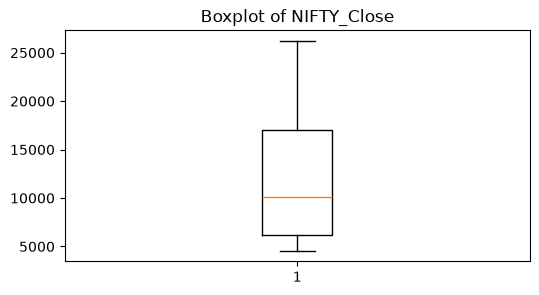

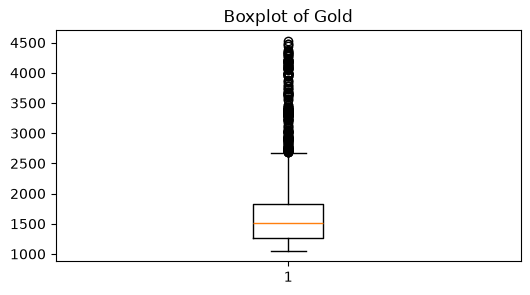

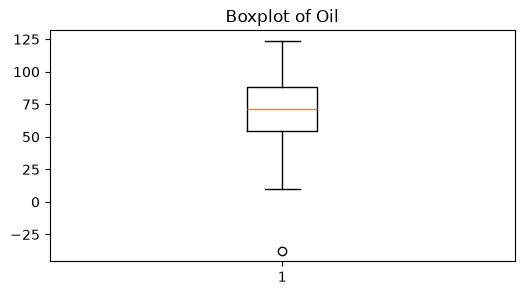

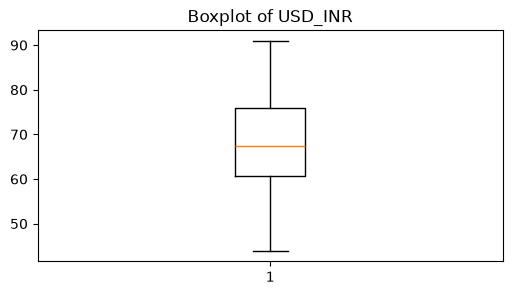

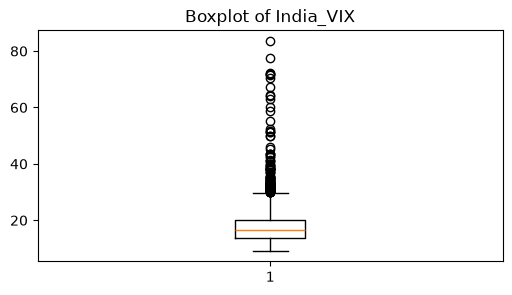

In [11]:
# Boxplots for Outlier Detection
columns_to_plot = ["NIFTY_Close", "Gold", "Oil", "USD_INR", "India_VIX"]
for col in columns_to_plot:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [12]:
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")

Date Range: 2010-01-04 00:00:00 to 2025-12-30 00:00:00


In [13]:
# Save clean dataset
df.to_csv("../data/processed/clean_market_data.csv", index=False)
print("Saved clean dataset to data/processed/clean_market_data.csv")

Saved clean dataset to data/processed/clean_market_data.csv
